# 03 — Results: what the split definition is worth

Everything here is read back from the committed `results/metrics.json`, so it reproduces
without a GPU and cannot drift away from the README.

The claim under test: **fine-tuning 148M parameters beats a frozen backbone with a 0.49M
head only on the split that lets it memorise complexes.**

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
METRICS = json.loads((ROOT / "results/metrics.json").read_text())

BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, MUTED, GRID = "#33322f", "#7a7975", "#e8e7e4"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "font.size": 9, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})

REPLICATES = ["split42_seed42", "split42_seed43", "split42_seed44",
              "split43_seed42", "split44_seed42"]
SPLITS = ["split_mutation", "split_pdb_id", "split_hold_out_proteins"]
METHODS = {
    "Frozen + ridge":  "linear_probe_ridge_esm2_t30_150M_UR50D",
    "Frozen + MLP":    "linear_probe_mlp_esm2_t30_150M_UR50D",
    "Fine-tuned 150M": "finetune_esm2_t30_150M_UR50D",
}

def test_rho(prefix, split, rep):
    return METRICS[f"{prefix}_{split}_{rep}"]["splits"][split]["test"]["spearman"]

print(f"{len(METRICS)} runs recorded in metrics.json")

57 runs recorded in metrics.json


## 1. The headline table

Five replicates per method per split: three training seeds at a fixed partition, and three
split seeds at a fixed training seed, overlapping at `split42/seed42`. Both variance sources
are measured because **neither dominates** — on some cells re-partitioning moves the number
more than retraining does.

In [2]:
rows = []
for name, prefix in METHODS.items():
    rec = {"method": name}
    for split in SPLITS:
        v = [test_rho(prefix, split, r) for r in REPLICATES]
        rec[split] = f"{np.mean(v):+.3f} ± {np.std(v, ddof=1):.3f}"
    rows.append(rec)

zs = METRICS["zero_shot_esm2_t30_150M_UR50D"]["splits"]
rows.insert(0, {"method": "Zero-shot (no training)",
                **{s: f"{zs[s]['test']['spearman']:+.3f}" for s in SPLITS}})
pd.DataFrame(rows).set_index("method")

,split_mutation,split_pdb_id,split_hold_out_proteins
method,,,
Zero-shot (no training),-0.082,+0.005,-0.097
Frozen + ridge,+0.473 ± 0.021,+0.053 ± 0.057,+0.122 ± 0.102
Frozen + MLP,+0.623 ± 0.024,+0.223 ± 0.020,+0.272 ± 0.053
Fine-tuned 150M,+0.660 ± 0.021,+0.178 ± 0.059,+0.167 ± 0.091


Zero-shot is the control that makes the rest interpretable. It never trains, so its score
is the *intrinsic difficulty* of each test set — and it is ≈0 on all three. The three test
sets are therefore comparably hard, which means the spread across the columns below is
caused by training, not by one split happening to be easier.

## 2. The training curves — the mechanism, not just the outcome

This is the most direct evidence in the project. Every trajectory below is the same model,
the same hyperparameters and the same data. **The only variable is which rows were held
out.**

- Under the naive split, validation contains *other mutations of complexes already in
  training*. Memorising an interface and learning ΔΔG are indistinguishable to that
  validation set, so the curve climbs for ten straight epochs and never signals a stop.
- Under `split_pdb_id` it peaks early and decays.
- Under the strictest split it peaks at **epoch 0** and goes negative.

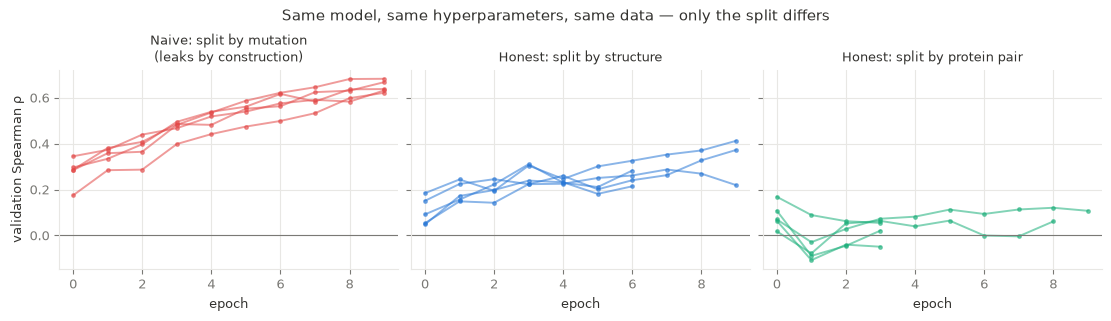

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), sharey=True, constrained_layout=True)
titles = {
    "split_mutation": "Naive: split by mutation\n(leaks by construction)",
    "split_pdb_id": "Honest: split by structure",
    "split_hold_out_proteins": "Honest: split by protein pair",
}
colours = {"split_mutation": RED, "split_pdb_id": BLUE, "split_hold_out_proteins": AQUA}

for ax, split in zip(axes, SPLITS):
    for rep in REPLICATES:
        hist = METRICS[f"finetune_esm2_t30_150M_UR50D_{split}_{rep}"]["training"]["history"]
        ax.plot([e["epoch"] for e in hist], [e["val_spearman"] for e in hist],
                color=colours[split], lw=1.4, alpha=0.55, marker="o", ms=2.5)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_title(titles[split], fontsize=9.5, color=INK)
    ax.set_xlabel("epoch"); ax.grid(True); ax.set_xlim(-0.4, 9.4)

axes[0].set_ylabel("validation Spearman ρ")
fig.suptitle("Same model, same hyperparameters, same data — only the split differs",
             fontsize=10.5, color=INK)
plt.show()

In [4]:
# Best epoch per run: where each split definition stops rewarding more training.
rows = []
for split in SPLITS:
    best = [METRICS[f"finetune_esm2_t30_150M_UR50D_{split}_{r}"]["training"]["best_epoch"]
            for r in REPLICATES]
    n_ep = [len(METRICS[f"finetune_esm2_t30_150M_UR50D_{split}_{r}"]["training"]["history"])
            for r in REPLICATES]
    rows.append({"split": split, "best epochs": best,
                 "median best": int(np.median(best)), "epochs run": n_ep})
pd.DataFrame(rows).set_index("split")

,best epochs,median best,epochs run
split,,,
split_mutation,"[9, 9, 9, 9, 9]",9,"[10, 10, 10, 10, 10]"
split_pdb_id,"[9, 3, 9, 3, 7]",7,"[10, 7, 10, 7, 10]"
split_hold_out_proteins,"[5, 0, 8, 0, 0]",0,"[9, 4, 10, 4, 4]"


## 3. Is the difference real? Paired over identical partitions

Comparing the two methods' *means* would ignore that they were evaluated on the same five
partitions. Pairing removes the partition as a source of variance, which is the whole reason
the replicates were run at matched seeds.

In [5]:
rows = []
for split in SPLITS:
    diffs = np.array([test_rho(METHODS["Fine-tuned 150M"], split, r)
                      - test_rho(METHODS["Frozen + MLP"], split, r) for r in REPLICATES])
    t, p = stats.ttest_rel(
        [test_rho(METHODS["Fine-tuned 150M"], split, r) for r in REPLICATES],
        [test_rho(METHODS["Frozen + MLP"], split, r) for r in REPLICATES])
    sem = stats.sem(diffs)
    lo, hi = stats.t.interval(0.95, len(diffs) - 1, loc=diffs.mean(), scale=sem)
    rows.append({"split": split, "mean Δρ": f"{diffs.mean():+.3f}",
                 "95% CI": f"[{lo:+.3f}, {hi:+.3f}]", "p": f"{p:.3f}",
                 "verdict": "fine-tune better" if p < 0.05 and diffs.mean() > 0
                            else ("probe better" if p < 0.05 else "not distinguishable")})
pd.DataFrame(rows).set_index("split")

,mean Δρ,95% CI,p,verdict
split,,,,
split_mutation,+0.038,"[+0.003, +0.072]",0.038,fine-tune better
split_pdb_id,-0.045,"[-0.133, +0.043]",0.229,not distinguishable
split_hold_out_proteins,-0.105,"[-0.256, +0.045]",0.124,not distinguishable


**Fine-tuning wins on exactly one split, and it is the leaky one.**

On the two honest splits the difference is not distinguishable from noise. That is a
narrower claim than "fine-tuning is worse", and it is the one the data supports — an
earlier version of this project asserted the stronger claim from single runs and had to
withdraw it.

## 4. Variance is a finding, not an inconvenience

Fine-tuning is 2–4× more variable than the probe. Fixing the random seed does **not** fix
this: the identical configuration produced 0.148 and 0.225 on two different days, from CUDA
kernel nondeterminism alone. That is why every number here is a five-replicate mean, and it
is the clearest target for the next round of work — shrink the spread, not just lift the
mean.

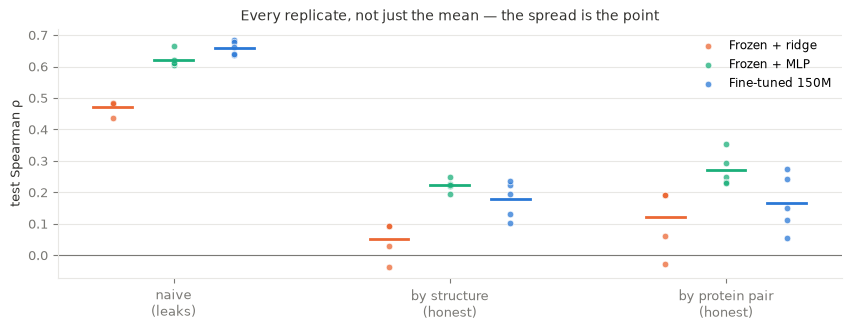

In [6]:
fig, ax = plt.subplots(figsize=(8.4, 3.2), constrained_layout=True)
x = np.arange(len(SPLITS))
for j, (name, prefix) in enumerate(METHODS.items()):
    vals = [[test_rho(prefix, s, r) for r in REPLICATES] for s in SPLITS]
    off = (j - 1) * 0.22
    colour = [ORANGE, AQUA, BLUE][j]
    for i, v in enumerate(vals):
        ax.scatter([i + off] * len(v), v, s=22, color=colour, alpha=0.75,
                   edgecolors="white", linewidths=0.6,
                   label=name if i == 0 else None, zorder=3)
        ax.plot([i + off - 0.07, i + off + 0.07], [np.mean(v)] * 2,
                color=colour, lw=2, zorder=4)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["naive\n(leaks)", "by structure\n(honest)", "by protein pair\n(honest)"])
ax.set_ylabel("test Spearman ρ"); ax.grid(True, axis="y")
ax.legend(frameon=False, fontsize=8.5, loc="upper right")
ax.set_title("Every replicate, not just the mean — the spread is the point",
             fontsize=10, color=INK)
plt.show()

In [7]:
spread = []
for name, prefix in METHODS.items():
    for split in SPLITS:
        v = [test_rho(prefix, split, r) for r in REPLICATES]
        spread.append({"method": name, "split": split,
                       "std": round(float(np.std(v, ddof=1)), 3),
                       "range": round(float(max(v) - min(v)), 3)})
pd.DataFrame(spread).pivot(index="method", columns="split", values="std")

split,split_hold_out_proteins,split_mutation,split_pdb_id
method,,,
Fine-tuned 150M,0.091,0.021,0.059
Frozen + MLP,0.053,0.024,0.020
Frozen + ridge,0.102,0.021,0.057


## 5. The antibody–antigen subset

SKEMPI labels interaction type, so this breakdown is free. It was pre-specified before any
results existed. It is also where the fine-tuned model behaves worst: its Spearman on
antibody complexes under the honest split is **below zero**, meaning the ranking is
anti-correlated with the measurements, in all five replicate pairs.

`split_hold_out_proteins` cannot support this claim — its test set holds only 6 AB/AG rows,
below the 10-row minimum — so the harness correctly omits the metric there and the claim
rests on `split_pdb_id` alone.

In [8]:
def ab_rho(prefix, split, rep):
    ea = METRICS[f"{prefix}_{split}_{rep}"]["error_analysis"].get("antibody_antigen")
    return None if not ea else ea.get("spearman")

rows = []
for name in ("Frozen + MLP", "Fine-tuned 150M"):
    rec = {"method": name}
    for split in ("split_pdb_id", "split_mutation"):
        v = [ab_rho(METHODS[name], split, r) for r in REPLICATES]
        v = [x for x in v if x is not None]
        rec[split] = f"{np.mean(v):+.3f} ± {np.std(v, ddof=1):.3f}" if v else "n/a (<10 rows)"
    rows.append(rec)

for split in ("split_pdb_id", "split_mutation"):
    ft = np.array([ab_rho(METHODS["Fine-tuned 150M"], split, r) for r in REPLICATES], float)
    pr = np.array([ab_rho(METHODS["Frozen + MLP"], split, r) for r in REPLICATES], float)
    d = ft - pr
    t, p = stats.ttest_rel(ft, pr)
    lo, hi = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=stats.sem(d))
    print(f"{split:16s} paired Δρ {d.mean():+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  p = {p:.3f}"
          f"   all five pairs negative: {bool((d < 0).all())}")
pd.DataFrame(rows).set_index("method")

split_pdb_id     paired Δρ -0.330  95% CI [-0.540, -0.119]  p = 0.012   all five pairs negative: True
split_mutation   paired Δρ -0.054  95% CI [-0.121, +0.012]  p = 0.086   all five pairs negative: False


,split_pdb_id,split_mutation
method,,
Frozen + MLP,+0.264 ± 0.052,+0.551 ± 0.042
Fine-tuned 150M,-0.065 ± 0.142,+0.497 ± 0.083


## 6. What this adds up to

| | |
|---|---|
| **Robust** | The leakage gradient. Fine-tune 0.66 on the leaky split against 0.18 on `split_pdb_id`; probe 0.62 against 0.22. Far beyond any noise measured here. |
| **Supported** | Fine-tuning beats the frozen probe only on the leaky split (+0.038, p = 0.038). |
| **Supported** | On antibody complexes under an honest split, fine-tuning is reliably *worse* (−0.330, p = 0.012). |
| **Not supported** | "Fine-tuning loses to the probe on the honest splits." Claimed from single runs; five replicates put p at 0.229 and 0.124. |
| **Not answerable here** | Whether a bigger backbone, position-specific pooling, or cross-chain attention closes the honest gap. |